# Datasets: what we have, how good the labels are, and how to split them

Real datasets only. Our generated data is in `synthetic_eda.ipynb`. The static summary is
[`docs/DATASETS.md`](../docs/DATASETS.md), and all logic is in `src/eda/`.

**Run:** `jupyter nbconvert --to notebook --execute --inplace notebooks/datasets_eda.ipynb`

| § | Section | Question it answers |
|---|---|---|
| 1 | Datasets at a glance | What is each dataset and what is it for? |
| 2 | Which file to use | Which file holds what, and which is derived from which? |
| 3 | Coding schemes | Are our code lists complete against the handbooks? |
| **4** | **Annotation quality** | **Can we trust the labels, and what hurts training?** |
| 5 | Overlaps | Which sessions appear in more than one dataset? |
| 6 | Cleaning audit | What needs fixing or a decision? |
| 7 | Dataset profiles | Size, length, label distributions, metadata |
| 8 | Splits | How each dataset is split, and what is excluded |
| 9 | Checks | Asserts on every number the docs quote |

### Key findings
1. **HLQC (our train set) uses FI as a catch-all.** 64% of standalone "okay"/"yeah"/"mm-hmm" are coded FI, where the manual says FA. FI is 19% of counsellor utterances against the manual's 5% ceiling, and only 7% of HLQC's FI are pleasantries, compared with 68% in the test set. The same label means different things in train and test. This barely hurts the MIV test score, but it makes HLQC-based evaluation (CV, the teacher gate) unreliable.
2. **HLQC under-codes client change talk.** On the same sessions, AnnoMI's experts hear change talk in 28 turns that HLQC calls neutral (κ 0.36). HLQC's client labels are 85% neutral, against 52% in the test set. As a result, 32% of test change/sustain talk is predicted neutral, and O+ recall is 0.03.
3. **The simple/complex reflection line differs between annotator groups.** The CASAA MITI reference codes HLQC's SRs as CR, while the MIV coders call long chatbot paraphrases SR. Test SR recall is 0.42, and 51% of test SRs are predicted CR, the largest single error.
4. **The test set's MI-consistent codes are nearly absent from training.** HLQC has SU 9, EC 22, and permission-seeking EC 1 (and that one is coded FI). Test recall: SU 0.39, EC 0.33.
5. **9% of training counsellor labels (ADW, RCW, WA, CO) never occur in the test set**, and 96–100% of them come from low-quality sessions. The model emits about 7 of them per test run.
6. **HLQC's text is noisy speech-to-text.** It has a word error rate of 9–25% against manual transcripts, 78% of its gold questions lack a "?", and 36% of its utterances start mid-sentence ("and/but/so…").
7. **Some training codes come from one session:** GI 75%, DI 75% and ADP 51% each come from a single session, so per-class CV is unstable.
8. **AnnoMI's "open" is not MISC's OQ.** In 68 of 114 shared questions, AnnoMI says "open" where the MISC rule (and HLQC) says CQ. The OQ/CQ gold in our AnnoMI transfer test is therefore not MISC-consistent.

In [1]:
import os, sys, json, warnings
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src')); os.chdir(ROOT)
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from eda import registry, overlap, clean, splits, stats, quality
pd.set_option('display.max_colwidth', 110); pd.set_option('display.max_rows', 120); pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', font_scale=0.9)
registry.ensure_downloads()
F = registry.load_all()
GOLD = ['misc.miv63a.gold', 'misc.hlqc.gold', 'annomi.gold', 'welivita.gold', 'miti.casaa.gold']
POOLS = ['pool.hlqc', 'pool.miv63a', 'pool.miv63b']

## 1. Datasets at a glance
One row per dataset. The ID is used everywhere, in code and docs.
- `misc.*` = MISC-coded gold;
- `pool.*` = unlabelled;
- `annomi` / `welivita` / `miti.casaa` = other schemes.

In [2]:
S = {k: stats.structure(v) for k, v in F.items()}
glance = pd.DataFrame([{
    'id': m.id, 'what it is': m.title, 'role': m.role,
    'sessions': S[m.id]['conversations'], 'units': S[m.id]['rows (units)'], 'coded units': S[m.id]['coded rows'],
    'scheme': m.scheme.split(',')[0], 'transcript': m.transcription}
    for m in registry.META.values() if m.id in F]).set_index('id')
glance

,what it is,role,sessions,units,coded units,scheme,transcript
id,,,,,,,
misc.miv63a.gold,"MIBot v6.3A, expert MISC consensus (TEST SET)",fixed test set for all MISC models,10,821,821,MISC 2.5 + AutoMISC extension (Activation AC+/-; AutoMISC T1 grouping),none (typed)
misc.hlqc.gold,"HLQC balanced subset, MISC 2.5 (TRAIN SET)",training set for all MISC models; few-shot / synthesis exemplars,10,1925,1925,MISC 2.5 + AutoMISC extension (Activation AC+/-; AutoMISC T1 grouping),"ASR (Pérez-Rosas et al. 2019), no casing/punctuation"
pool.hlqc,HLQC full corpus (UNLABELLED pool),"unlabelled pool (retrieval, self-training); contains misc.hlqc.gold",257,30610,0,none at utterance level (session high/low quality only),ASR
pool.miv63a,MIBot v6.3A full run (UNLABELLED pool),unlabelled pool; MUST exclude the 10 test sessions,173,13692,0,none,none
pool.miv63b,MIBot v6.3B run (UNLABELLED pool),unlabelled pool (self-training v2 'Step F'),165,11771,0,none,none
annomi.gold,AnnoMI (expert-annotated MI demonstrations),own-scheme train/dev/test; cross-scheme transfer test for MISC models,133,9699,9699,AnnoMI: therapist main behaviour + subtypes; client change/neutral/sustain,manual (professional)
welivita.gold,Welivita & Pu MI dataset (peer-support forums),own-scheme train/dev/test (agreed subset); weak cross-scheme test; self-training pool,2000,20462,16811,MITI-derived,none
miti.casaa.gold,CASAA MITI 4 coded training transcripts,test only (MITI; MISC on 6 exact T2 codes + T1),20,1346,682,MITI 4 (counsellor only),manual


## 2. Which file to use
Each corpus lives in several files. **Use the file whose *use it for* matches your task.** *Derived from* shows the
lineage, so you never count the same data twice. Traps:
- `data/HLQC.csv` and `data/parsed/HLQC_parsed.csv` are the unlabelled pool. The **train** set is `data/manual/HLQC_balanced_manual.csv`.
- `data/AnnoMI.csv` is AutoMISC's re-mapped copy, in a **different row order** from the official release. Join on `conv_id` + `utterance_id`.
- Welivita's labels are the original authors', in all three files.

In [3]:
registry.FILES.set_index(['dataset', 'file'])

level                                             labels                                          use it for  \
dataset          file                                                                                                                                                              
misc.miv63a.gold data/manual/MIV6.3A_manual.csv                 utterance    MISC T1/T2 human gold (*_GT) + GPT-4.1 (*_auto)                        TEST set of every MISC model   
misc.hlqc.gold   data/manual/HLQC_balanced_manual.csv           utterance                              MISC T1/T2 human gold                       TRAIN set; few-shot exemplars   
pool.hlqc        data/HLQC.csv                              turn (volley)                      none (session high/low in id)                                           raw turns   
                 data/parsed/HLQC_parsed.csv                    utterance                                               none          unlabelled pool (retrieval, self-training)   
pool.miv63a      data/MIV6.3A.csv                           turn (volley)                                               none                                           raw turns   
                 data/parsed/MIV6.3A_parsed.csv                 utterance                                               none    unlabelled pool (must drop the 10 test sessions)   
                 data/2024-11-14-MIV6.3A-...merged.csv        participant  readiness / importance / confidence, demographics  session outcomes (join 'Participant id' = conv_id)   
pool.miv63b      data/MIV6.3B.csv                           turn (volley)                                               none                                           raw turns   
                 data/parsed/MIV6.3B_parsed.csv                 utterance                                               none                     unlabelled pool (self-training)   
                 data/2024-11-19-MIV6.1B_...merged.csv        participant                                    survey outcomes              session outcomes (file name says 6.1B)   
annomi.gold      data/external/annomi/AnnoMI-full.csv    turn x annotator                    AnnoMI attributes per annotator        agreement analysis (7 ten-rater transcripts)   
                 data/external/annomi/AnnoMI-simple.csv              turn                  AnnoMI main behaviour / talk type                           own-scheme train/dev/test   
                 data/AnnoMI.csv                                     turn               MISC-mapped AnnoMI labels (AutoMISC)         source of AnnoMI_eval (different row order)   
                 data/manual/AnnoMI_eval.csv                         turn                     MISC gold on shared codes only                    cross-scheme TEST of MISC models   
                 data/parsed/AnnoMI_parsed.csv                  utterance                                               none                                utterance-split text   
welivita.gold    data/external/welivita/MI_Dataset.csv           sentence              ann1, ann2, judge stages, final label                agreement analysis; own-scheme split   
                 data/external/welivita_mi_parsed.csv            sentence                   final label + MISC map (weak_t2)                                  self-training pool   
                 data/manual/Welivita_eval.csv                   sentence                          MISC gold on shared codes                    cross-scheme TEST of MISC models   
miti.casaa.gold  data/external/casaa/CASAA_eval.csv             utterance                  MITI codes + MISC map where exact                MITI / MISC TEST (18 clean sessions)   
                 data/external/casaa/casaa_turns.csv                 turn                        raw code cell + coder notes                                  audit of the parse   
                 data/external/casaa/casaa_globals.csv            session                                MIT

## 3. Coding schemes vs the handbooks
The code lists come from the manuals (MISC 2.5, MITI 4.2.1) and the dataset papers (Welivita Table 1, AnnoMI §4), not from the
data. So a class we have no data for still shows up.

*Read:* `status = ok` means the code is in the handbook and in our vocabulary. *Gold datasets* lists where real examples exist; empty means no real data.

In [4]:
H = registry.handbook_check(F)
ab = {'misc.hlqc.gold':'HLQC','misc.miv63a.gold':'MIV','miti.casaa.gold':'CASAA','welivita.gold':'Welivita','annomi.gold':'AnnoMI'}
H['gold datasets'] = H.datasets_with_examples.map(lambda s: ', '.join(ab[x.strip()] for x in s.split(',') if x.strip() in ab))
print('Handbook classes with NO real example:'); display(H[(H.status == 'ok') & (H['gold datasets'] == '')][['scheme','speaker','code']])
print('Codes we use that are NOT in the handbook:'); display(H[H.status.str.startswith(('extension', 'in data'))][['scheme','code','status']])
print('MISC 2.5 items we do not use: No Code (NC); reflection valence; globals', registry.HANDBOOK['MISC 2.5']['globals'])

Handbook classes with NO real example:


,scheme,speaker,code
11,MISC 2.5,counsellor,RCP
31,MISC 2.5,client,TS-


Codes we use that are NOT in the handbook:


,scheme,code,status
35,MISC 2.5,AC+,"extension (not in handbook): AutoMISC addition (Activation; thesis footnote 1 cites Miller & Rollnick, Mot..."
36,MISC 2.5,AC-,extension (not in handbook): AutoMISC addition (Activation-); not in MISC 2.5.
47,MITI 4.2.1,NC,"in data, not in handbook (CASAA transcript convention)"
48,MITI 4.2.1,SAME,"in data, not in handbook (CASAA transcript convention)"


MISC 2.5 items we do not use: No Code (NC); reflection valence; globals ['Acceptance', 'Empathy', 'Direction', 'Autonomy Support', 'Collaboration', 'Evocation', 'Self-Exploration (client)']


In [5]:
H[['scheme','speaker','code','manual_group','status','gold datasets']]

,scheme,speaker,code,manual_group,status,gold datasets
0,MISC 2.5,counsellor,ADP,MICO,ok,"HLQC, MIV"
1,MISC 2.5,counsellor,ADW,MIIN,ok,HLQC
2,MISC 2.5,counsellor,AF,MICO,ok,"HLQC, MIV"
3,MISC 2.5,counsellor,CO,MIIN,ok,HLQC
4,MISC 2.5,counsellor,DI,MIIN,ok,"HLQC, MIV"
5,MISC 2.5,counsellor,EC,MICO,ok,"HLQC, MIV"
6,MISC 2.5,counsellor,FA,neither,ok,"HLQC, MIV"
7,MISC 2.5,counsellor,FI,neither,ok,"HLQC, MIV"
8,MISC 2.5,counsellor,GI,neither,ok,"HLQC, MIV"
9,MISC 2.5,counsellor,OQ,MICO,ok,"HLQC, MIV"


Crosswalk to MISC: other schemes map **only where the concepts are identical**.

In [6]:
for name, t in registry.schemes().items():
    if name != 'MISC 2.5':
        print('===', name); display(t)

=== MITI 4.2.1 (CASAA)


,code,meaning,misc_t1,misc_t2,mapping,source
0,GI,Giving information,IMC,GI,exact,MITI 4.2.1
1,Persuade,Persuade,None,None,none,MITI 4.2.1
2,Persuade with Permission,Persuade with permission,None,None,none,MITI 4.2.1
3,Q,Question (open/closed not split),Q,None,T1 only,MITI 4.2.1
4,SR,Simple reflection,SRL,SR,exact,MITI 4.2.1
5,CR,Complex reflection,CRL,CR,exact,MITI 4.2.1
6,AF,Affirm,CRL,AF,exact,MITI 4.2.1
7,Seek,Seeking collaboration,None,None,none,MITI 4.2.1
8,Emphasize,Emphasizing autonomy,CRL,EC,exact,MITI 4.2.1
9,Confront,Confront,IMI,CO,exact,MITI 4.2.1


=== Welivita MITI-derived


,code,misc_t2,misc_t1,mapping,source
0,Closed Question,CQ,Q,exact,Welivita & Pu 2022 Table 1
1,Open Question,OQ,Q,exact,Welivita & Pu 2022 Table 1
2,Simple Reflection,SR,SRL,exact,Welivita & Pu 2022 Table 1
3,Complex Reflection,CR,CRL,exact,Welivita & Pu 2022 Table 1
4,Give Information,GI,IMC,exact,Welivita & Pu 2022 Table 1
5,Advise with Permission,ADP,IMC,exact,Welivita & Pu 2022 Table 1
6,Affirm,AF,CRL,exact,Welivita & Pu 2022 Table 1
7,Emphasize Autonomy,EC,CRL,exact,Welivita & Pu 2022 Table 1
8,Support,SU,CRL,exact,Welivita & Pu 2022 Table 1
9,Advise without Permission,ADW,IMI,exact,Welivita & Pu 2022 Table 1


=== AnnoMI


,speaker,attribute,subtype,misc,mapping
0,therapist,question,open,OQ,exact
1,therapist,question,closed,CQ,exact
2,therapist,reflection,simple,SR,exact
3,therapist,reflection,complex,CR,exact
4,therapist,input,information,GI,exact
5,therapist,input,advice,ADP/ADW,permission unknown
6,therapist,input,negotiation/goal-setting,None,none
7,therapist,input,options,None,none
8,therapist,other (main behaviour),None,None,none
9,client,change,None,C (T1),T1 only


## 4. Annotation quality: can we trust the labels, and what hurts training?
Mainly the **train** set (`misc.hlqc.gold`) against the **test** set (`misc.miv63a.gold`), through six lenses:

| § | Lens | Evidence type |
|---|---|---|
| 4.1 | Codebook rules | MISC 2.5 manual rules testable on text, e.g. "OK" = FA, FI ≤ 5%, "could you…?" = CQ |
| 4.2 | What FI contains | the same label's meaning in train vs test |
| 4.3 | Identical text, different label | internal consistency |
| 4.4 | **Independent coders on the same sessions** | AnnoMI experts (4 shared sessions), CASAA MITI reference (Emmy = high_121) |
| 4.5 | Transcription and segmentation | ASR word error, missing "?", mid-sentence cuts |
| 4.6 | Reflections | the SR/CR line |
| 4.7 | Train → test label shift and session concentration | what the model sees vs what it is tested on |
| 4.8 | **Impact on the main model** | `ft1mix_bare` errors on the test set (3 seeds) |

Rule checks are heuristics: they flag *candidate* violations, and every rule cites the manual page.

### 4.1 Codebook rules (MISC 2.5 manual)

In [7]:
A = quality.codebook_audit()
A[['dataset','rule','manual says','applicable','flagged','flagged %','flagged label mix']]

,dataset,rule,manual says,applicable,flagged,flagged %,flagged label mix
0,misc.hlqc.gold,"standalone acknowledgement ('okay', 'yeah', 'mm-hmm', 'right' ...)","FA (p.22: 'keep-going acknowledgments ... OK, Right, Mm Hmm'); GI if answering a client question",121,77,63.6,{'FI': 77}
1,misc.hlqc.gold,share of counsellor utterances coded FI,"FI is rare: 'if these exceed 5% of Counselor responses, they probably are being over-coded' (p.24)",1040,198,19.0,{}
2,misc.hlqc.gold,"question starting with an auxiliary verb ('do you', 'could you', 'is it' ...)","CQ: 'if the question can be answered by yes/no, it is a closed question'; 'Could you tell me...' = CQ (p.28)",41,1,2.4,{'OQ': 1}
3,misc.hlqc.gold,'tell me ...' requests,"OQ ('Tell me more.' / 'Tell me about your family.' = OQ, p.26)",1,0,0.0,{}
4,misc.hlqc.gold,scaling / ruler questions,"CQ ('On a scale of 1 to 10, how much ...?' = CQ, p.28)",6,0,0.0,{}
5,misc.hlqc.gold,utterance ending in '?' coded as a reflection,"a reflection with upward inflection is a (closed) question ('spoiled reflection' = CQ, p.27)",55,2,3.6,"{'CR': 1, 'SR': 1}"
6,misc.hlqc.gold,short counsellor reply right after a client question,"GI ('Responses to client questions are typically coded as Giving Information, even if brief', p.23)",0,0,NaN,{}
7,misc.hlqc.gold,client ruler answer that is just a number,"0-4 = sustain talk, 5 = FN, 6-10 = change talk (p.40)",0,0,NaN,{}
8,misc.hlqc.gold,"permission-seeking ('would it be okay if...', 'do you mind if...', 'can I share...')",EC: 'permission-seeking utterances are coded as a separate utterance of Emphasize Control' (p.16),1,1,100.0,{'FI': 1}
9,misc.hlqc.gold,questions (OQ/CQ gold) with no '?' in the text,"(transcript property, not a rule) - the model cannot see the question mark",222,174,78.4,"{'CQ': 97, 'OQ': 77}"


**Takeaway.** HLQC breaks the FA/FI rule in 64% of applicable cases and is 4x over the FI ceiling. Its question conventions
(CQ for "do/could/is…", scale questions) follow the manual. MIV's FI share (9.7%) is also above 5%, but it consists of real pleasantries.
78% of HLQC's gold questions have no "?" because ASR drops punctuation, so the model must detect questions from words alone.

### 4.2 What FI actually contains: same label, different meaning

,misc.hlqc.gold (n=198),misc.miv63a.gold (n=56)
acknowledgement (codebook: FA),0.389,0.054
other / longer statement,0.348,0.250
short fragment (<=3 words),0.197,0.018
pleasantry (codebook: FI),0.066,0.679


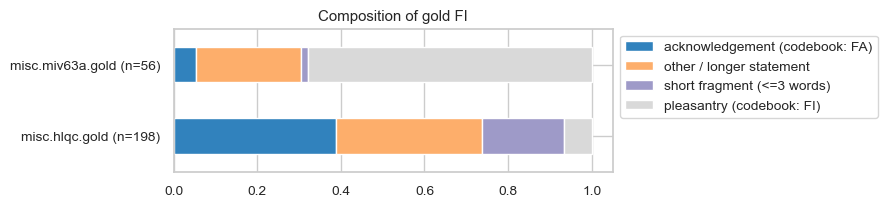

In [8]:
fc = quality.fi_content(); display(fc)
fc.T.plot.barh(stacked=True, figsize=(9, 2.2), colormap='tab20c'); plt.title('Composition of gold FI'); plt.legend(bbox_to_anchor=(1, 1)); plt.tight_layout(); plt.show()

**Takeaway.** In train, FI mostly means acknowledgement or fragment. In test, it means pleasantry. Section 4.8 shows the model
still labels test pleasantries FI (95%), so this distorts HLQC-based evaluation more than the MIV test.

### 4.3 Identical text, different label (internal consistency)

In [9]:
it = quality.identical_text('misc.hlqc.gold')
print('HLQC train - repeated utterances with more than one label:'); display(it[it.n_labels > 1].head(12))
print('MIV test - repeated utterances with more than one label:'); display(quality.identical_text('misc.miv63a.gold', 2).query('n_labels > 1'))
print('Same text in both train and test:'); display(quality.train_test_convention())

HLQC train - repeated utterances with more than one label:


,speaker,k,n,labels,n_labels,majority share
0,counsellor,okay,34,"{'FI': 24, 'FA': 10}",2,0.71
1,counsellor,yeah,29,"{'FA': 15, 'FI': 14}",2,0.52
2,counsellor,mmhmm,11,"{'FA': 6, 'FI': 5}",2,0.55
3,counsellor,mmhm,7,"{'FI': 5, 'FA': 2}",2,0.71
4,counsellor,yeah yeah,6,"{'FA': 4, 'FI': 2}",2,0.67
5,counsellor,all right,5,"{'FI': 4, 'FA': 1}",2,0.80
6,counsellor,oh,4,"{'FI': 2, 'FA': 2}",2,0.50
7,counsellor,uhhuh,4,"{'FA': 3, 'FI': 1}",2,0.75
8,counsellor,or,3,"{'CQ': 2, 'FI': 1}",2,0.67


MIV test - repeated utterances with more than one label:


,speaker,k,n,labels,n_labels,majority share
0,counsellor,i'm glad to hear that,4,"{'FI': 2, 'AF': 1, 'SU': 1}",3,0.50
1,counsellor,great,4,"{'FI': 3, 'FA': 1}",2,0.75
2,counsellor,that's perfectly fine,2,"{'FI': 1, 'SU': 1}",2,0.50


Same text in both train and test:


,speaker,k,train labels,test labels,n,same majority
0,client,no,{'N': 4},{'N': 14},18,True
1,client,okay,{'N': 14},{'N': 1},15,True
2,client,yes,{'N': 4},{'N': 6},10,True
3,client,thanks,{'N': 5},{'N': 2},7,True
4,counsellor,all right,"{'FI': 4, 'FA': 1}",{'FA': 1},6,False
5,counsellor,how are you doing today,"{'FI': 1, 'OQ': 1}",{'OQ': 4},6,False
6,counsellor,great,{'FI': 1},"{'FI': 3, 'FA': 1}",5,True
7,client,ok,{'N': 1},{'N': 3},4,True


### 4.4 Independent coders on the same sessions
Four HLQC train sessions are also AnnoMI transcripts, coded by AnnoMI's experts in AnnoMI's scheme. HLQC `high_121` is CASAA's *Emmy*,
coded by the MITI developers' lab. Utterances are aligned by word-level sequence matching. Both references code **whole turns**, so the
comparison is made per reference turn: HLQC's *main* label is its longest substantive utterance in that turn.

*Read:* compare κ with the reference group's own reliability. AnnoMI's raters among themselves reach 0.74 (counsellor) and 0.47 (client).

In [10]:
X = quality.cross_annotation()
display(X['wer'].rename(columns={'words_hyp': 'HLQC words', 'words_ref': 'reference words'}))
summ = []
for k, label in [('annomi_counsellor', 'HLQC vs AnnoMI - counsellor main behaviour (per turn)'),
                 ('annomi_client', 'HLQC vs AnnoMI - client talk type (per turn)'),
                 ('annomi_open_closed', 'HLQC OQ/CQ vs AnnoMI open/closed'),
                 ('annomi_simple_complex', 'HLQC SR/CR vs AnnoMI simple/complex'),
                 ('casaa_counsellor', 'HLQC vs CASAA MITI reference (per turn)')]:
    v = X[k]; summ.append({'comparison': label, 'n': v['n'], 'agreement': v.get('agreement'), 'kappa': v.get('kappa')})
display(pd.DataFrame(summ))
for k in ['annomi_client', 'annomi_open_closed', 'casaa_counsellor']:
    print(k); display(X[k]['confusion'])

,hlqc,reference,HLQC words,reference words,matched,WER
0,low_001,AnnoMI 53,1786,1849,1707,0.088
1,low_080,AnnoMI 15,581,601,546,0.106
2,high_099,AnnoMI 21,2516,2802,2346,0.172
3,low_033,AnnoMI 44,1771,2013,1656,0.188
4,high_121,CASAA Emmy,3662,3436,2976,0.253


,comparison,n,agreement,kappa
0,HLQC vs AnnoMI - counsellor main behaviour (per turn),194,0.722,0.584
1,HLQC vs AnnoMI - client talk type (per turn),185,0.746,0.364
2,HLQC OQ/CQ vs AnnoMI open/closed,114,0.395,0.067
3,HLQC SR/CR vs AnnoMI simple/complex,21,0.810,0.538
4,HLQC vs CASAA MITI reference (per turn),34,0.441,0.319


annomi_client


independent coder,change,neutral,sustain
HLQC gold,,,
change,18,3,1
neutral,28,118,12
sustain,1,2,2


annomi_open_closed


independent coder,closed,open
HLQC gold,,
closed,10,68
open,1,35


casaa_counsellor


independent coder,AF,CR,Emphasize,GI,Persuade,Q,Seek
HLQC gold,,,,,,,
AF,0,0,0,1,0,0,0
CR,1,7,0,0,0,1,0
Emphasize,0,0,2,0,0,0,0
GI,0,0,0,1,1,0,0
NC,0,0,1,1,0,0,1
PwP,0,0,0,0,0,0,1
Q,0,1,0,0,0,5,1
SR,0,9,0,0,0,0,0


In [11]:
am = X['annomi_pairs']; c = am[am.speaker == 'counsellor']
ex = c[(c.hlqc_t2 == 'CQ') & (c.annomi_sub == 'open')]
print('HLQC CQ but AnnoMI "open" - examples (MISC rule: yes/no or specific-fact questions are CQ):')
for t in ex.hlqc_text.drop_duplicates().head(8): print('  -', t[:110])
print('AnnoMI annotator behind these rows:', ex.annomi_annotator.value_counts().to_dict())

HLQC CQ but AnnoMI "open" - examples (MISC rule: yes/no or specific-fact questions are CQ):
  - are you doing school
  - what kind of grades do you get
  - and do you know where you're going to apply to college
  - so do you drink alcohol
  - and how often do you think you drink
  - what do you think's the most you've ever had
  - all right have you ever done that
  - have you ever done
AnnoMI annotator behind these rows: {3: 44, 4: 22, 6: 2}


**Takeaway.**
- **Counsellor behaviour** (κ 0.58 per turn) is in the range expected between expert groups.
- **Client talk** (κ 0.36): HLQC calls neutral much of what AnnoMI calls change talk.
- **Open/closed:** HLQC follows the MISC rule. AnnoMI's "open" (mostly annotator 3) includes MISC-CQ.
- **Reflections:** against the MITI reference, HLQC's SRs are often CR.

### 4.5 Transcription and segmentation

In [12]:
quality.segmentation()

dataset,misc.hlqc.gold,misc.miv63a.gold
counsellor utterances,1040,580
utterances per counsellor turn (mean),2.66,3.79
turns split into >= 3 utterances %,38.4,92.2
utterances <= 3 words %,18.6,4.3
utterances starting with and/but/or/so/because %,35.8,0.5
reflections that continue a reflection in the same turn %,46.4,47.2
SR : CR,137 : 85,134 : 42


**Takeaway.** HLQC's utterances are often cut mid-sentence (36% start with and/but/or/so/because, against 0.5% in test), and 19% are
three words or fewer. Fragments get FI or are split out of a longer reflection.

### 4.6 Reflections: where is the simple/complex line?

In [13]:
display(quality.reflection_style())

,dataset,code,n,median words,>= 15 words %
0,misc.hlqc.gold,SR,137,11.0,30.7
1,misc.hlqc.gold,CR,85,12.0,34.1
2,misc.miv63a.gold,SR,134,18.0,73.1
3,misc.miv63a.gold,CR,42,15.5,57.1


**Takeaway.** Inside HLQC, SR and CR are about the same length, so there is no length shortcut. Test SRs, however, are long, polished chatbot
paraphrases (median 18 words) that the MIV coders call *simple*. Combined with 4.4, the three annotator groups (CASAA, HLQC, MIV) put the
SR/CR line in three different places.

### 4.7 Train → test label shift, and where each training code comes from

,speaker,code,train n,test n,train %,test %,ratio train/test,only in
0,counsellor,FI,198,56,19.0,9.7,1.97,
1,counsellor,SR,137,134,13.2,23.1,0.57,
2,counsellor,CQ,132,75,12.7,12.9,0.98,
3,counsellor,OQ,90,79,8.7,13.6,0.64,
4,counsellor,CR,85,42,8.2,7.2,1.13,
5,counsellor,ADP,81,42,7.8,7.2,1.08,
6,counsellor,ST,76,13,7.3,2.2,3.26,
7,counsellor,FA,55,4,5.3,0.7,7.67,
8,counsellor,ADW,31,0,3.0,0.0,inf,train
9,counsellor,RCW,25,0,2.4,0.0,inf,train


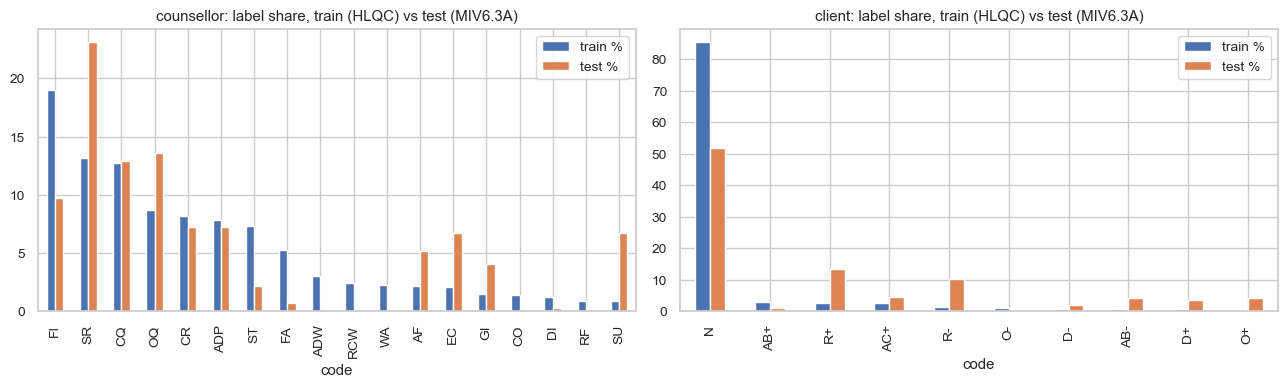

Training mass on codes the test never has: {'client': 13, 'counsellor': 95}


In [14]:
sh = quality.shift()
display(sh)
top = sh[sh['test n'] + sh['train n'] >= 10].copy()
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for i, spk in enumerate(['counsellor', 'client']):
    t = top[top.speaker == spk].set_index('code')[['train %', 'test %']]
    t.plot.bar(ax=ax[i], title=f'{spk}: label share, train (HLQC) vs test (MIV6.3A)')
plt.tight_layout(); plt.show()
print('Training mass on codes the test never has:',
      sh[sh['only in'] == 'train'].groupby('speaker')['train n'].sum().to_dict())

In [15]:
co = quality.concentration(); co

,speaker,code,n,sessions,top session,top session share,from low-quality sessions %
0,counsellor,FI,198,10,low_026,0.18,52.0
1,counsellor,SR,137,10,high_121,0.23,40.0
2,counsellor,CQ,132,10,high_099,0.27,46.0
3,counsellor,OQ,90,8,high_099,0.26,41.0
4,counsellor,CR,85,6,low_026,0.34,49.0
5,counsellor,ADP,81,6,low_031,0.51,78.0
6,counsellor,ST,76,7,high_117,0.30,38.0
7,counsellor,FA,55,6,low_026,0.31,51.0
8,counsellor,ADW,31,4,low_031,0.48,100.0
9,counsellor,RCW,25,5,low_001,0.44,96.0


**Takeaway.**
- MI-consistent codes that are common in the test set (SU, EC, AF, GI) are rare in training.
- ADW/RCW/WA/CO (9% of training counsellor labels) never occur in the test, and come 96–100% from low-quality sessions.
- Some codes (GI, DI, ADP) come mostly from a single session.

### 4.8 Impact on the main model (`ft1mix_bare`, MIV6.3A test, 3 seeds)
Do the issues above show up as test errors?

In [16]:
I = quality.impact()
display(I['summary'])
display(I['recall_by_code'])

,value
test utterances x seeds,2463.000
gold FI pleasantries predicted FI,0.947
gold client change/sustain predicted N,0.316
gold SU recall,0.385
gold EC recall,0.325
predictions of train-only codes (per seed),7.300


,speaker,t2_label_GT,n_per_seed,recall
24,counsellor,SR,134,0.423
22,counsellor,OQ,79,0.958
15,counsellor,CQ,75,0.840
20,counsellor,FI,56,0.905
13,counsellor,ADP,42,0.746
16,counsellor,CR,42,0.857
18,counsellor,EC,39,0.325
26,counsellor,SU,39,0.385
14,counsellor,AF,30,0.600
21,counsellor,GI,24,0.542


In [17]:
for k in ['gold_FI_predicted_as', 'gold_change_sustain_predicted_as', 'predictions_of_train_only_codes']:
    print(k); display(I[k])

gold_FI_predicted_as


pred,AF,CR,EC,FI,SU
kind,,,,,
other FI,0.00,0.11,0.06,0.81,0.02
pleasantry,0.02,0.00,0.00,0.95,0.04


gold_change_sustain_predicted_as


,share of gold change/sustain-talk predictions
pred,
N,0.316
R+,0.181
R-,0.141
AC+,0.101
D+,0.086
D-,0.043
AB-,0.040
AB+,0.034
C+,0.014


predictions_of_train_only_codes


,pred,t2_label_GT,count over 3 seeds
0,C-,AB-,2
1,O-,AB-,2
2,O-,N,2
3,RCW,ADP,3
4,RCW,GI,8
5,WA,GI,5


**Summary of the quality issues**

| Issue | Evidence | Effect on the MIV test | Possible action (not applied) |
|---|---|---|---|
| FI used for acknowledgements/fragments in HLQC | 4.1–4.3 | small: test FI pleasantries still predicted FI (95%) | relabel standalone acknowledgements FI→FA in a derived train copy; treat HLQC-CV numbers with care |
| HLQC under-codes change talk | 4.4 client κ 0.36; 85% neutral vs 52% | **large**: 32% of change/sustain predicted neutral; O+ recall 0.03 | re-annotate HLQC client turns, or reweight non-neutral client labels |
| SR/CR line differs between annotator groups | 4.4, 4.6 | **largest single error**: 51% of test SR predicted CR | adjudicate a shared SR/CR guideline; consider scoring reflections at T1 too |
| SU / EC (incl. permission-seeking) almost absent from training | 4.1, 4.7 | SU 0.39, EC 0.33 recall | targeted examples (human or synthetic) for SU, EC and permission-seeking |
| Train-only IMI codes from low-quality sessions | 4.7 | ~7 spurious predictions per run | downweight, or map to T1 only |
| ASR noise and mid-sentence segmentation | 4.5 | indirect: fragments, missing "?" | re-segment HLQC, or use corrected transcripts (MI-TAGS if obtained) |
| AnnoMI "open" ≠ MISC OQ | 4.4 | affects the AnnoMI transfer test, not MIV | score AnnoMI questions at T1 (Q) only |

## 5. Overlaps: which sessions appear in more than one dataset?
Detector: 5-gram containment between conversations, ignoring phrases that occur in more than 5 conversations, so chatbot templates are
ignored. A score ≥ 0.10 is a real link; unrelated sessions score ≤ 0.02.

Two kinds of link:
- **duplicate session**: the same session under two ids, e.g. two uploads of one video;
- **same opening post, different reply**: Welivita only; one CounselChat question answered by several therapists.

In [18]:
P = overlap.pairwise(F)
CL = overlap.classify(P, F)
tab = CL.groupby(['dataset_a', 'dataset_b', 'kind']).agg(pairs=('containment', 'size'), max_containment=('containment', 'max')).reset_index()
tab

,dataset_a,dataset_b,kind,pairs,max_containment
0,annomi.gold,misc.hlqc.gold,duplicate session,4,0.692
1,annomi.gold,pool.hlqc,duplicate session,68,0.851
2,misc.hlqc.gold,miti.casaa.gold,duplicate session,1,0.397
3,misc.hlqc.gold,pool.hlqc,duplicate session,6,0.949
4,miti.casaa.gold,pool.hlqc,duplicate session,2,0.397
5,pool.hlqc,pool.hlqc,duplicate session,53,1.000
6,welivita.gold,welivita.gold,duplicate session,30,1.000
7,welivita.gold,welivita.gold,partial overlap,10,0.921
8,welivita.gold,welivita.gold,"same opening post, different reply",316,0.720


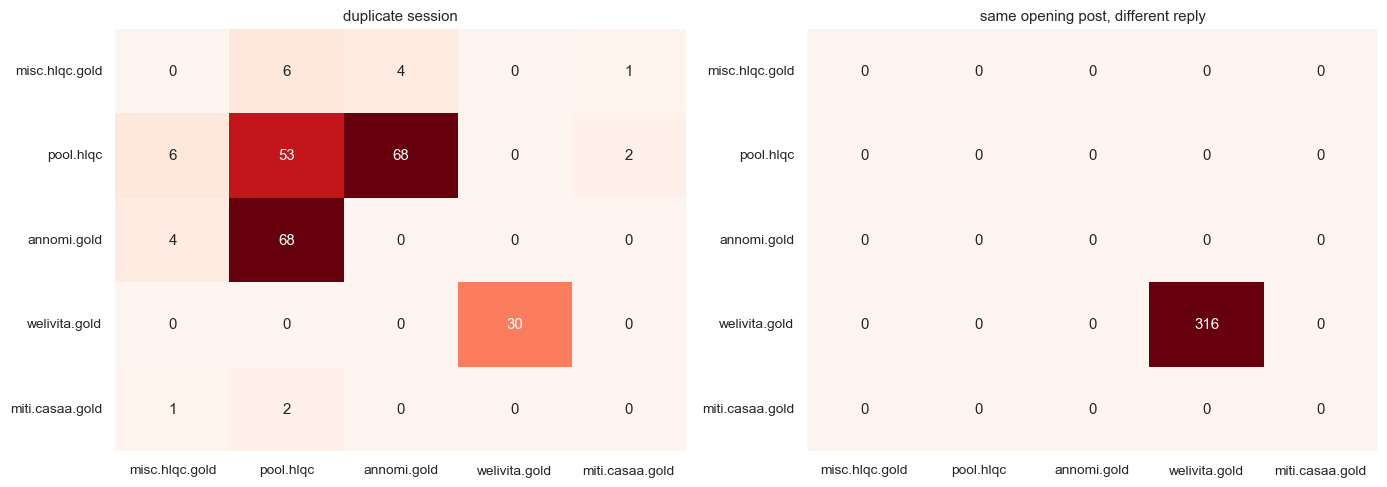

In [19]:
ids = [k for k in F if k in set(CL.dataset_a) | set(CL.dataset_b)]
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for i, kind in enumerate(['duplicate session', 'same opening post, different reply']):
    M = pd.DataFrame(0, index=ids, columns=ids)
    for a, b in zip(CL[CL.kind == kind].dataset_a, CL[CL.kind == kind].dataset_b):
        M.loc[a, b] += 1
        if a != b: M.loc[b, a] += 1
    sns.heatmap(M, annot=True, fmt='d', cmap='Reds', cbar=False, ax=ax[i]); ax[i].set_title(kind)
plt.tight_layout(); plt.show()

**Why some datasets have many duplicates and others none:**
- **HLQC pool:** scraped from YouTube/Vimeo, so the same demo was often uploaded more than once.
- **Welivita:** mostly the same question with different therapists' answers. The labels are on the answers, so these are kept but always placed in the same split.
- **AnnoMI and CASAA:** curated lists of distinct videos.
- **MIV:** every session is a different participant.

In [20]:
def pairs_of(a, b):
    x = CL[((CL.dataset_a == a) & (CL.dataset_b == b)) | ((CL.dataset_a == b) & (CL.dataset_b == a))]
    return x[['dataset_a','conv_a','dataset_b','conv_b','containment']].reset_index(drop=True)
print('HLQC TRAIN sessions that appear elsewhere (leak risk for any test built from those datasets):')
for other in ['annomi.gold', 'miti.casaa.gold', 'pool.hlqc']:
    t = pairs_of('misc.hlqc.gold', other); display(t[t.conv_a != t.conv_b])
print('MIV6.3A TEST sessions that appear elsewhere:', len(CL[(CL.dataset_a == 'misc.miv63a.gold') | (CL.dataset_b == 'misc.miv63a.gold')]))

HLQC TRAIN sessions that appear elsewhere (leak risk for any test built from those datasets):


,dataset_a,conv_a,dataset_b,conv_b,containment
0,annomi.gold,53,misc.hlqc.gold,low_001,0.692
1,annomi.gold,15,misc.hlqc.gold,low_080,0.668
2,annomi.gold,21,misc.hlqc.gold,high_099,0.663
3,annomi.gold,44,misc.hlqc.gold,low_033,0.618


,dataset_a,conv_a,dataset_b,conv_b,containment
0,misc.hlqc.gold,high_121,miti.casaa.gold,casaa_emmys-first-encounter,0.397


,dataset_a,conv_a,dataset_b,conv_b,containment
0,misc.hlqc.gold,low_026,pool.hlqc,high_084,0.949
1,misc.hlqc.gold,low_001,pool.hlqc,low_027,0.930
2,misc.hlqc.gold,low_001,pool.hlqc,low_040,0.901
3,misc.hlqc.gold,low_080,pool.hlqc,low_019,0.874
4,misc.hlqc.gold,low_031,pool.hlqc,low_054,0.821
5,misc.hlqc.gold,low_080,pool.hlqc,low_098,0.595


MIV6.3A TEST sessions that appear elsewhere: 0


In [21]:
display(overlap.known_relations(F))

,dataset_a,dataset_b,relation,detail,verified
0,misc.hlqc.gold,pool.hlqc,subset,the 10 gold sessions are pool sessions (same conv_id),10/10 misc.hlqc.gold sessions found in pool.hlqc
1,misc.miv63a.gold,pool.miv63a,subset,the 10 test sessions are pool sessions (same conv_id),10/10 misc.miv63a.gold sessions found in pool.miv63a
2,annomi.gold,annomi.gold,derived,AnnoMI-full -> AnnoMI-simple -> data/AnnoMI.csv (AutoMISC MISC map) -> data/manual/AnnoMI_eval.csv; parsed...,
3,welivita.gold,welivita.gold,derived,release MI_Dataset.csv -> external/welivita_mi_parsed.csv -> manual/Welivita_eval.csv; selftrain pseudo-la...,


## 6. Cleaning audit
Only rows that need action or a decision are shown. No data file is modified: duplicates and leaks are handled by exclusion lists in `data/splits/`.

In [22]:
AU = clean.run(F, P)
AU.loc[AU.dataset == 'miti.casaa.gold', 'example'] = ''
AU[(AU.severity != 'info') | AU.action.str.startswith(('decide', 'drop', 'fix', 'dedupe', 'exclude', 'split'))].reset_index(drop=True)

,dataset,check,n,share,example,severity,action
0,misc.miv63a.gold,short utterances (>=3 occurrences) with conflicting T2,1,0.1429,'great',warn,"annotation noise: report, do not relabel"
1,misc.hlqc.gold,T1 inconsistent with T2 group,6,0.0031,Q/ST,error,fix in derived copy
2,misc.hlqc.gold,short utterances (>=3 occurrences) with conflicting T2,9,0.3333,"'okay', 'yeah', 'mmhmm'",warn,"annotation noise: report, do not relabel"
3,pool.miv63a,empty / whitespace text,2,0.0001,,warn,drop in derived copy
4,annomi.gold,short utterances (>=3 occurrences) with conflicting T2,4,0.8000,"'yeah', 'okay', 'no'",warn,"annotation noise: report, do not relabel"
5,welivita.gold,short utterances (>=3 occurrences) with conflicting T2,19,0.5000,"'good luck', 'yes', 'be well'",warn,"annotation noise: report, do not relabel"
6,pool.hlqc,near-duplicate sessions inside the pool (containment >= 0.5),51,0.1984,low_003=low_005; low_008=low_048; high_011=high_014,warn,dedupe pool in derived copy (keep one per cluster)
7,pool.hlqc,duplicate sessions with CONFLICTING high/low quality label,4,0.0784,high_025=low_086; high_084=low_026; high_036=low_051,warn,decide (session-quality label unreliable for these)
8,pool.hlqc,copies of HLQC GOLD (train) sessions under another pool id,6,0.6000,low_026=high_084; low_001=low_027; low_001=low_040; low_080=low_019; low_031=low_054; low_080=low_098,warn,exclude from pool when the pool is used for evaluation
9,welivita.gold,duplicate dialogues (containment >= 0.9),9,0.0045,counsel_chat | 100=counsel_chat | 1857; counsel_chat | 1856=counsel_chat | 99,warn,split by duplicate cluster; dedupe in derived copy


In [23]:
t1_of = clean.misc_vocab(); h = F['misc.hlqc.gold']
print('HLQC train rows whose T1 contradicts the T2 group (needs a decision):')
h[[t1_of.get((s, c)) not in (None, t) for s, c, t in zip(h.speaker, h.t2, h.t1)]][['conv_id','utt_idx','speaker','text','t1','t2']]

HLQC train rows whose T1 contradicts the T2 group (needs a decision):


,conv_id,utt_idx,speaker,text,t1,t2
453,high_117,142,counsellor,so how does that sound to you?,Q,ST
604,high_121,120,counsellor,"I just wanna say we, we can go over some things that are potential to talk about to really focus on that m...",CRL,ST
809,high_127,7,counsellor,so let's talk more about what brought you in today,O,OQ
1523,low_031,156,counsellor,tell me a little bit about those,O,OQ
1546,low_031,179,counsellor,where would you put yourself on how important this is to you,O,CQ
1547,low_031,180,counsellor,want to say on a scale of one to ten just just on importance,O,CQ


## 7. Dataset profiles
### 7.1 Size, length and text style

In [24]:
prof = pd.DataFrame({k: {**stats.structure(v), **stats.text_quality(v)} for k, v in F.items()}).T
prof[['conversations','rows (units)','counsellor rows','client rows','units / conv (median)','words / unit (median)',
      'has uppercase','has sentence punctuation','contains filler (um/uh/mm-hmm/you know)']]

,conversations,rows (units),counsellor rows,client rows,units / conv (median),words / unit (median),has uppercase,has sentence punctuation,contains filler (um/uh/mm-hmm/you know)
misc.miv63a.gold,10,821,580,241,78.5,12.0,0.847747,0.825822,0.003654
misc.hlqc.gold,10,1925,1040,885,228.0,8.0,0.424935,0.195844,0.142857
pool.hlqc,257,30610,15898,14712,97.0,8.0,0.417543,0.098987,0.103953
pool.miv63a,173,13692,9835,3857,76.0,12.0,0.888037,0.812299,0.001461
pool.miv63b,165,11771,6844,4927,69.0,12.0,0.726531,0.63478,0.001189
annomi.gold,133,9699,4882,4817,47.0,9.0,0.962367,0.932673,0.307867
welivita.gold,2000,20462,17261,3201,9.0,16.0,0.962418,0.972046,0.007624
miti.casaa.gold,20,1346,687,659,76.0,17.0,0.998514,0.907875,0.184993


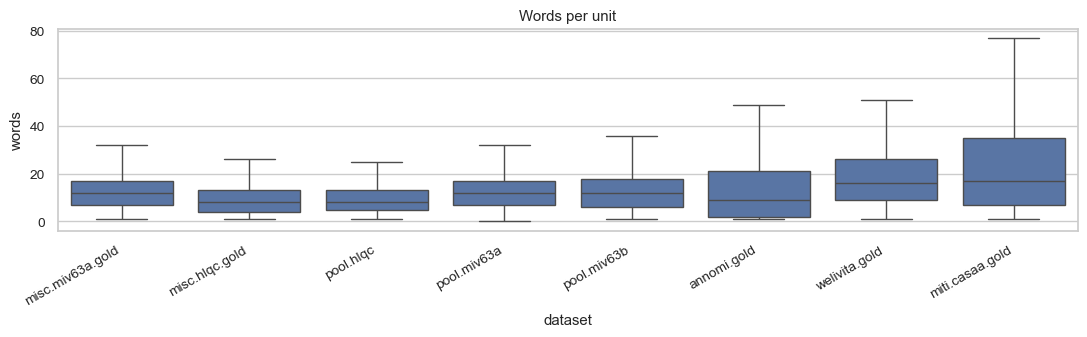

In [25]:
L = pd.concat([pd.DataFrame({'dataset': k, 'words': v.text.astype(str).str.split().str.len()}) for k, v in F.items()])
plt.figure(figsize=(11, 3.5)); sns.boxplot(data=L, x='dataset', y='words', showfliers=False)
plt.xticks(rotation=30, ha='right'); plt.title('Words per unit'); plt.tight_layout(); plt.show()

### 7.2 Label distributions (red = tail: < 1% or < 20 examples)

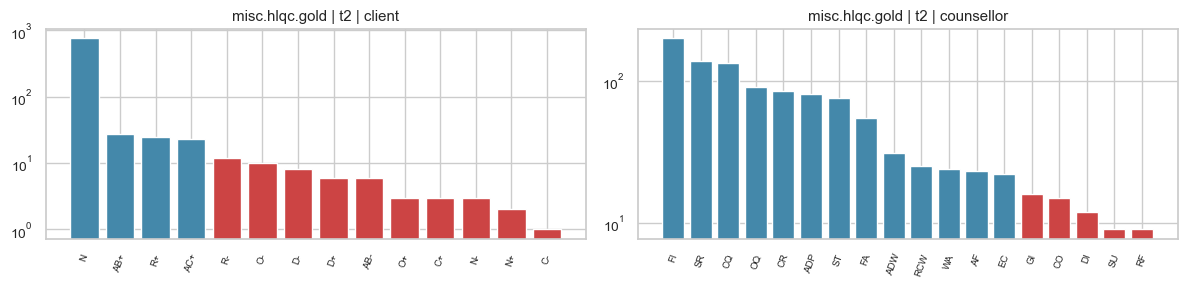

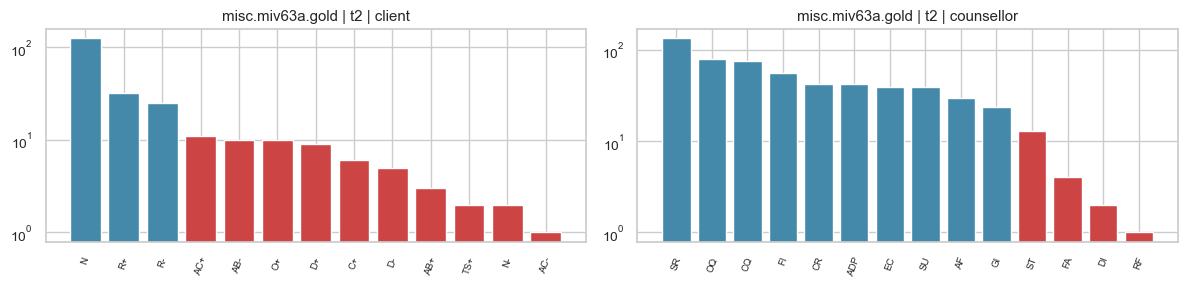

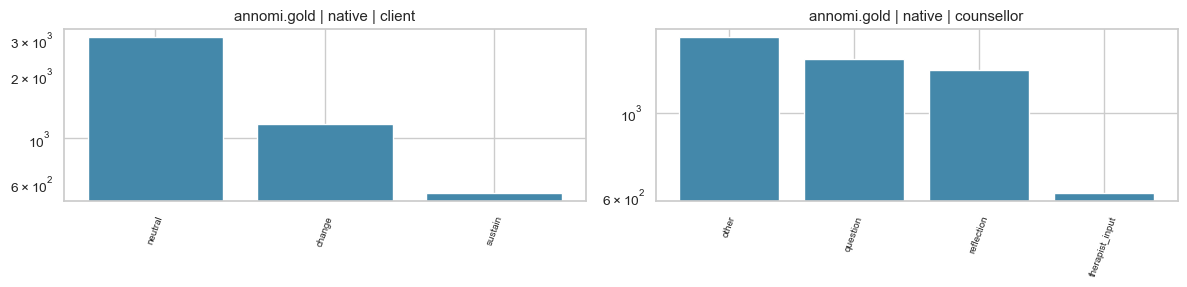

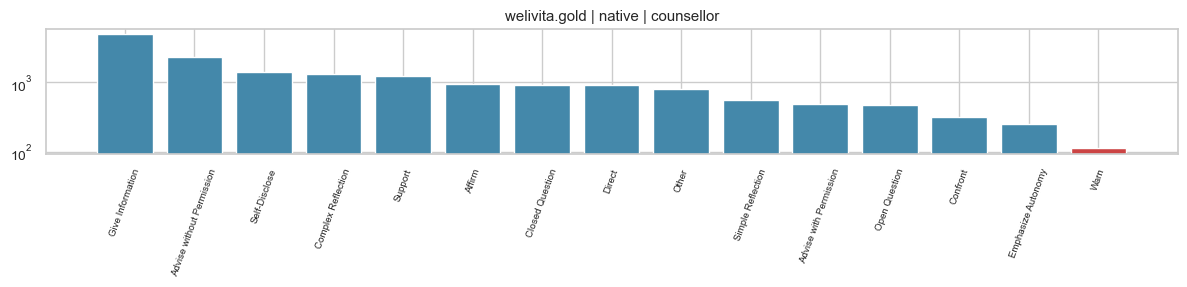

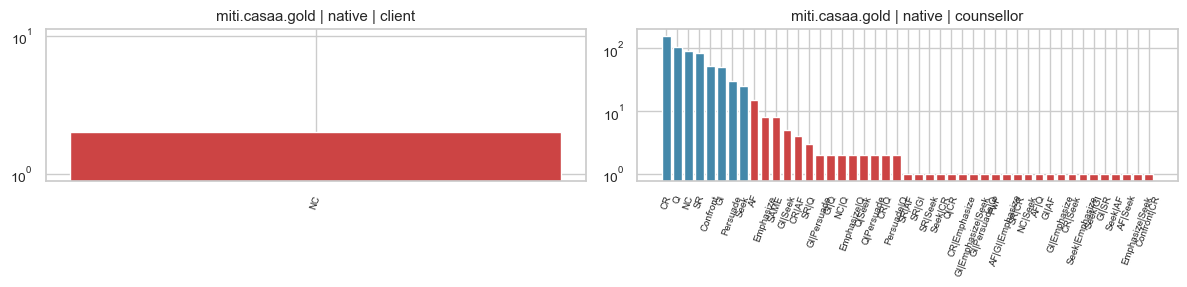

In [26]:
def label_plot(ds, col):
    lt = stats.label_table(F[ds], col)
    if lt.empty: return
    spk = sorted(lt.speaker.unique())
    fig, ax = plt.subplots(1, len(spk), figsize=(12, 3), squeeze=False)
    for i, s in enumerate(spk):
        g = lt[lt.speaker == s].sort_values('n', ascending=False)
        ax[0, i].bar(g.code, g.n, color=['#c44' if t else '#48a' for t in g['is_tail']])
        ax[0, i].set_yscale('log'); ax[0, i].set_title(f'{ds} | {col} | {s}'); ax[0, i].tick_params(axis='x', rotation=70, labelsize=7)
    plt.tight_layout(); plt.show()
for ds, col in [('misc.hlqc.gold', 't2'), ('misc.miv63a.gold', 't2'), ('annomi.gold', 'native'), ('welivita.gold', 'native'), ('miti.casaa.gold', 'native')]:
    label_plot(ds, col)

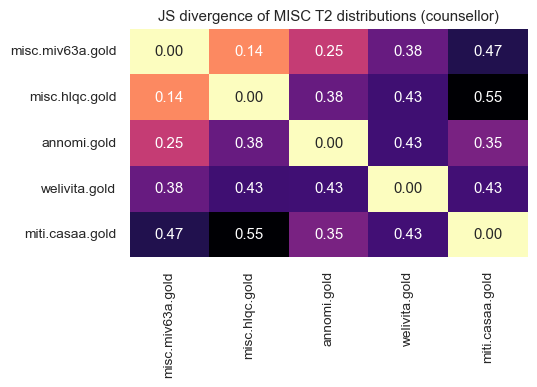

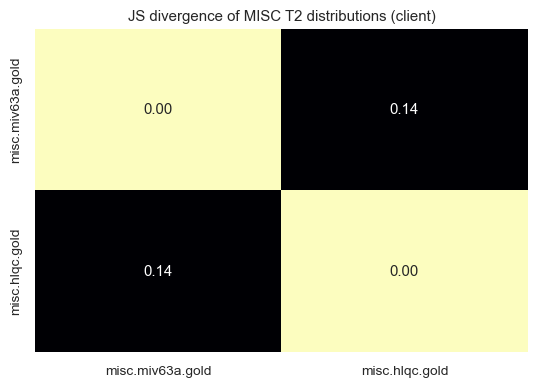

In [27]:
for spk in ['counsellor', 'client']:
    J = stats.js_matrix({k: F[k] for k in GOLD}, spk, 't2')
    if len(J) > 1:
        plt.figure(figsize=(5.5, 4)); sns.heatmap(J, annot=True, fmt='.2f', cmap='magma_r', cbar=False)
        plt.title(f'JS divergence of MISC T2 distributions ({spk})'); plt.tight_layout(); plt.show()

### 7.3 Dataset-specific metadata and agreement

AnnoMI MI quality: {'high': 110, 'low': 23}


,transcripts
topic,
reducing alcohol consumption,23
smoking cessation,19
taking medicine / following medical procedure,8
reducing recidivism,7
more exercise / increasing activity,7
reducing drug use,7
weight loss,6
unidentifiable,5
asthma management,5


AnnoMI agreement (7 ten-rater transcripts): {'fleiss_main': 0.737, 'fleiss_client': 0.467, 'fleiss_reflection_subtype': 0.496, 'fleiss_question_subtype': 0.74, 'fleiss_therapist_input_subtype': 0.512}


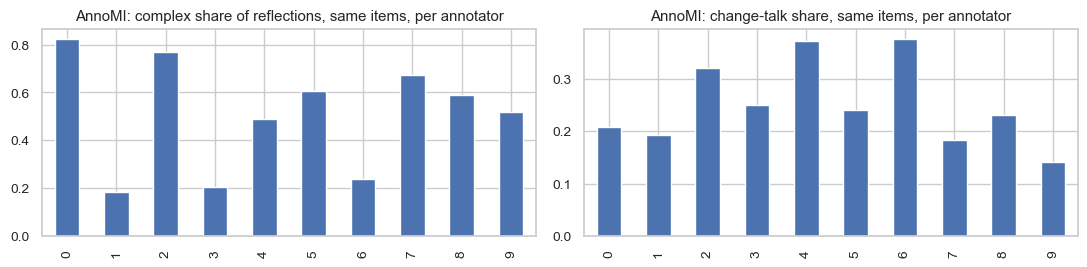

Welivita agreement: {'n': 17261, 'raw_agreement': 0.414, 'kappa': 0.34, 'stage1_agreed': 7152}


In [28]:
an = F['annomi.gold']; sess = an.groupby('conv_id').agg(quality=('mi_quality','first'), topic=('topic','first'))
print('AnnoMI MI quality:', sess.quality.value_counts().to_dict()); display(sess.topic.value_counts().head(10).to_frame('transcripts'))
ag = registry.annomi_agreement()
print('AnnoMI agreement (7 ten-rater transcripts):', {k: round(v, 3) for k, v in ag.items() if k.startswith('fleiss')})
fig, ax = plt.subplots(1, 2, figsize=(11, 2.8))
pd.Series(ag['complex_share_same_items']).plot.bar(ax=ax[0], title='AnnoMI: complex share of reflections, same items, per annotator')
pd.Series(ag['change_share_same_items']).plot.bar(ax=ax[1], title='AnnoMI: change-talk share, same items, per annotator')
plt.tight_layout(); plt.show()
print('Welivita agreement:', {k: round(v, 3) if isinstance(v, float) else v for k, v in registry.welivita_agreement().items()})

In [29]:
o = registry.miv_outcomes('A'); test = set(F['misc.miv63a.gold'].conv_id)
cols = ['pre_importance','post_importance','pre_confidence','post_confidence','pre_readiness','post_readiness']
display(o[cols].describe().T[['count','mean','std']].round(2))
print('delta confidence, test sessions vs rest:', o[o.conv_id.isin(test)].delta_confidence.mean().round(2), 'vs', o[~o.conv_id.isin(test)].delta_confidence.mean().round(2))
print('HLQC session quality labels:', pd.Series([c[:4] for c in F['pool.hlqc'].conv_id.unique()]).value_counts().to_dict())
display(pd.read_csv('data/external/casaa/casaa_globals.csv').set_index('conv_id'))

,count,mean,std
pre_importance,173.0,6.20,2.48
post_importance,173.0,6.92,2.64
pre_confidence,173.0,4.27,2.66
post_confidence,173.0,5.62,2.69
pre_readiness,173.0,5.86,2.67
post_readiness,173.0,6.54,2.64


delta confidence, test sessions vs rest: 1.9 vs 1.31
HLQC session quality labels: {'high': 154, 'low_': 103}


,CCT,SST,PAR,EMP
conv_id,,,,
casaa_i-guess-i-dont-have-a-choice,1,4,1,1
casaa_maybe-hell-take-my-kids,2,2,2,2
casaa_should-i-really-be-honest,3,2,5,5
casaa_the-confirmed-smoker,4,4,5,5
casaa_session1miti,2,2,2,3
casaa_session2miti,2,1,1,2
casaa_session3miti,3,3,3,4
casaa_session4miti,4,3,3,3
casaa_session5miti,1,1,1,1


## 8. Splits (`data/splits/*.json`, built by `python -m eda.splits`)
- **MISC main** (unchanged): train `misc.hlqc.gold`; test `misc.miv63a.gold` plus CASAA minus its HLQC duplicates; dev = 5-fold HLQC CV.
- **AnnoMI** and **Welivita**: their own schemes, split by conversation.
- **Pools**: exclusion lists.

In [30]:
MAN = {p.stem: json.load(open(p)) for p in sorted(Path('data/splits').glob('*.json')) if p.stem != 'synthetic'}
mm = MAN['misc_main']
print('MISC train:', mm['train']['misc.hlqc.gold'])
print('MISC test:', {k: len(v) for k, v in mm['test'].items()})
for k, v in mm['exclude'].items(): print('exclude', k, '->', v)

MISC train: ['high_001', 'high_099', 'high_117', 'high_121', 'high_127', 'low_001', 'low_026', 'low_031', 'low_033', 'low_080']
MISC test: {'misc.miv63a.gold': 10, 'miti.casaa.gold (MISC-mapped)': 18}
exclude annomi.gold (when the model also saw pool.hlqc: self-training/retrieval arms) -> ['2', '3', '8', '9', '15', '17', '19', '21', '23', '24', '27', '32', '33', '36', '40', '44', '50', '52', '53', '59', '65', '66', '68', '69', '72', '74', '80', '82', '87', '90', '91', '92', '97', '102', '103', '106', '107', '112', '113', '114', '115', '118', '119', '123', '126', '127', '130', '131']
exclude annomi.gold (when used as transfer test of HLQC-gold-trained models) -> ['15', '21', '44', '53']
exclude miti.casaa.gold -> ['casaa_emmys-first-encounter', 'casaa_rounder-miti-4']


In [31]:
def split_cov(ds, split_map):
    df = F[ds].copy(); df['split'] = df.conv_id.map(split_map)
    if ds == 'welivita.gold': df = df[(df.speaker != 'counsellor') | df.stage1_agreed]
    return pd.crosstab([df.speaker, df.native], df.split)
print('AnnoMI transcripts per split:', pd.Series(MAN['annomi_own']['split']).value_counts().to_dict())
display(split_cov('annomi.gold', MAN['annomi_own']['split']))
print('Welivita dialogues per split:', pd.Series(MAN['welivita_own']['split']).value_counts().to_dict())
display(split_cov('welivita.gold', MAN['welivita_own']['split']))
for p, v in MAN['pools'].items():
    if isinstance(v, dict): print(p, {k: (len(x) if isinstance(x, list) else x) for k, x in v.items() if k != 'notes'})

AnnoMI transcripts per split: {'train': 91, 'dev': 22, 'test': 20}


split                       dev  test  train
speaker    native                           
client     change           340   120    714
           neutral          666   478   1958
           sustain          131    96    314
counsellor other            388   216    982
           question         306   216    864
           reflection       336   172    788
           therapist_input  115   100    399

Welivita dialogues per split: {'train': 1604, 'test': 200, 'dev': 196}


split                                 dev  test  train
speaker    native                                     
counsellor Advise with Permission       5     3     49
           Advise without Permission   74    95    656
           Affirm                      36    36    270
           Closed Question             55    65    527
           Complex Reflection          24    25    212
           Confront                     6    14     58
           Direct                      23    30    199
           Emphasize Autonomy           5     5     32
           Give Information           207   231   1911
           Open Question               29    31    302
           Other                       21    25    299
           Self-Disclose              101    81    702
           Simple Reflection           15    11    106
           Support                     54    52    462
           Warn                         1     1      6

pool.hlqc {'exclude_always': 0, 'exclude_if_annomi_is_test': 63, 'exclude_if_casaa_is_test': 2, 'gold_sessions_and_their_copies': 16, 'redundant_duplicates': 45}
pool.miv63a {'exclude_always': 10}
pool.miv63b {'exclude_always': 0}


## 9. Checks (fail loudly if a number quoted in the docs drifts)

In [32]:
assert len(F['misc.miv63a.gold']) == 821 and len(F['misc.hlqc.gold']) == 1925
assert len(F['annomi.gold']) == 9699 and len(F['welivita.gold']) == 20462 and len(F['miti.casaa.gold']) == 1346
assert abs(ag['fleiss_main'] - 0.737) < 1e-3 and abs(registry.welivita_agreement()['kappa'] - 0.340) < 1e-3
r = A.set_index(['dataset', 'rule'])
assert r.loc[('misc.hlqc.gold', "standalone acknowledgement ('okay', 'yeah', 'mm-hmm', 'right' ...)"), 'flagged %'] == 63.6
assert r.loc[('misc.hlqc.gold', 'share of counsellor utterances coded FI'), 'flagged %'] == 19.0
assert X['annomi_client']['kappa'] == 0.364 and X['annomi_counsellor']['kappa'] == 0.584
assert float(I['summary'].loc['gold client change/sustain predicted N', 'value']) == 0.316
pairs = set(zip(CL.conv_a, CL.conv_b)) | set(zip(CL.conv_b, CL.conv_a))
assert ('high_121', 'casaa_emmys-first-encounter') in pairs and ('high_072', 'casaa_rounder-miti-4') in pairs
assert splits.check(splits.build(F, P), F) == []
print('all checks passed')

all checks passed
